In [1]:
# Imports
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.patches import Circle

from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u

# Step 1

In [2]:
# Read VOT file from query
file_path = "data/ngc362_astr5140_wyz5rge-result.vot"  # change if needed

# Read as Astropy table
table = Table.read(file_path)

# print(table)
# print(len(table))

# Convert to pandas
df = table.to_pandas()

print(df.head())
print(df.columns)

             SOURCE_ID         ra        dec  parallax  parallax_error  \
0  4690603362443889792  15.934139 -71.346349  0.096548        0.260422   
1  4690603366746232192  15.913384 -71.341228  0.216941        0.108877   
2  4690603431163391360  15.897498 -71.336370 -0.050133        0.173684   
3  4690603431163393024  15.910591 -71.334075 -0.078073        0.271482   
4  4690603912199718528  15.707385 -71.341805 -0.048383        0.097834   

        pmra  pmra_error     pmdec  pmdec_error  phot_g_mean_mag  \
0  -0.594375    0.253857 -1.660841     0.265577        19.179611   
1  11.523517    0.114568  1.518508     0.114977        17.970472   
2   0.352691    0.184003 -1.212226     0.190410        18.542339   
3   1.076076    0.277447 -1.281891     0.294585        19.315510   
4   0.898562    0.108275 -1.252751     0.102734        17.837690   

   phot_bp_mean_mag  phot_rp_mean_mag     bp_rp      ruwe  radial_velocity  \
0         19.416954         18.571383  0.845572  1.014365           

In [3]:
# NGC 362 center from assignment
ra_center = 15.8094167      # deg
dec_center = -70.8487778    # deg

# Half-light radius
r_h_arcmin = 0.82
r_h_deg = r_h_arcmin / 60.0

# Query radius you used
query_radius_arcmin = 30.0
query_radius_deg = query_radius_arcmin / 60.0

# Sky coordinates
cluster_center = SkyCoord(ra=ra_center*u.deg, dec=dec_center*u.deg, frame="icrs")
source_coords = SkyCoord(ra=df["ra"].values*u.deg, dec=df["dec"].values*u.deg, frame="icrs")

# Angular separation from cluster center
df["radius_deg"] = source_coords.separation(cluster_center).deg
df["radius_arcmin"] = df["radius_deg"] * 60.0

# Convenience photometric columns
if "phot_bp_mean_mag" in df.columns and "phot_rp_mean_mag" in df.columns:
    df["bp_rp_manual"] = df["phot_bp_mean_mag"] - df["phot_rp_mean_mag"]

# Convenience flags for later cleaning
df["has_bp"] = df["phot_bp_mean_mag"].notna() if "phot_bp_mean_mag" in df.columns else False
df["has_rp"] = df["phot_rp_mean_mag"].notna() if "phot_rp_mean_mag" in df.columns else False
df["has_color"] = df["has_bp"] & df["has_rp"]

df["has_pm"] = df["pmra"].notna() & df["pmdec"].notna()
df["has_parallax"] = df["parallax"].notna()

print(df[["ra", "dec", "radius_arcmin", "has_color", "has_pm", "has_parallax"]].head())

          ra        dec  radius_arcmin  has_color  has_pm  has_parallax
0  15.934139 -71.346349      29.952515       True    True          True
1  15.913384 -71.341228      29.616065       True    True          True
2  15.897498 -71.336370      29.305625       True    True          True
3  15.910591 -71.334075      29.184184       True    True          True
4  15.707385 -71.341805      29.648053       True    True          True


In [4]:
summary = pd.DataFrame({
    "non_null": df.notna().sum(),
    "null": df.isna().sum(),
    "fraction_null": df.isna().mean()
}).sort_values("fraction_null", ascending=False)

summary.head(20)

,non_null,null,fraction_null
radial_velocity_error,338,54539,0.993841
radial_velocity,338,54539,0.993841
ruwe,43376,11501,0.209578
parallax,43376,11501,0.209578
parallax_error,43376,11501,0.209578
pmra,43376,11501,0.209578
pmra_error,43376,11501,0.209578
pmdec,43376,11501,0.209578
pmdec_error,43376,11501,0.209578
bp_rp,44735,10142,0.184813


In [5]:
print(f"Total sources downloaded: {len(df):,}")
print(f"Sources with BP and RP magnitudes: {df['has_color'].sum():,}")
print(f"Sources with proper motions: {df['has_pm'].sum():,}")
print(f"Sources with parallaxes: {df['has_parallax'].sum():,}")

print(f"\nCluster center: RA={ra_center:.6f} deg, Dec={dec_center:.6f} deg")
print(f"Half-light radius: {r_h_arcmin:.2f} arcmin")
print(f"Query radius: {query_radius_arcmin:.1f} arcmin")

Total sources downloaded: 54,877
Sources with BP and RP magnitudes: 44,735
Sources with proper motions: 43,376
Sources with parallaxes: 43,376

Cluster center: RA=15.809417 deg, Dec=-70.848778 deg
Half-light radius: 0.82 arcmin
Query radius: 30.0 arcmin


# Step 2

In [6]:
# Start from the full downloaded table
df_step2 = df.copy()

# Must have BP and RP to build CMD
mask_color = (
    df_step2["phot_bp_mean_mag"].notna() &
    df_step2["phot_rp_mean_mag"].notna() &
    df_step2["phot_g_mean_mag"].notna()
)

# Require finite astrometry for later plots
mask_astrometry = (
    df_step2["pmra"].notna() &
    df_step2["pmdec"].notna() &
    df_step2["parallax"].notna()
)

# Gaia astrometric-quality cut: RUWE < 1.4
if "ruwe" in df_step2.columns:
    mask_ruwe = df_step2["ruwe"].notna() & (df_step2["ruwe"] < 1.4)
else:
    mask_ruwe = np.ones(len(df_step2), dtype=bool)

# Keep a few versions for later comparison
df_color = df_step2[mask_color].copy()
df_color_astrom = df_step2[mask_color & mask_astrometry].copy()
df_clean = df_step2[mask_color & mask_astrometry & mask_ruwe].copy()

print(f"Raw sample:                  {len(df_step2):,}")
print(f"With BP/RP/G only:           {len(df_color):,}")
print(f"With BP/RP/G + astrometry:   {len(df_color_astrom):,}")
print(f"With BP/RP/G + astrometry + RUWE<1.4: {len(df_clean):,}")

Raw sample:                  54,877
With BP/RP/G only:           44,735
With BP/RP/G + astrometry:   38,876
With BP/RP/G + astrometry + RUWE<1.4: 36,363


In [7]:
# add color column to cleaned tables
for d in [df_color, df_color_astrom, df_clean]:
    d["bp_rp"] = d["phot_bp_mean_mag"] - d["phot_rp_mean_mag"]

# summarize cuts
cut_summary = pd.DataFrame({
    "sample": ["raw", "color", "color+astrometry", "color+astrometry+ruwe"],
    "N_sources": [len(df_step2), len(df_color), len(df_color_astrom), len(df_clean)]
})

cut_summary["fraction_remaining"] = cut_summary["N_sources"] / len(df_step2)
cut_summary

,sample,N_sources,fraction_remaining
0,raw,54877,1.000000
1,color,44735,0.815187
2,color+astrometry,38876,0.708421
3,color+astrometry+ruwe,36363,0.662627


# Step 3

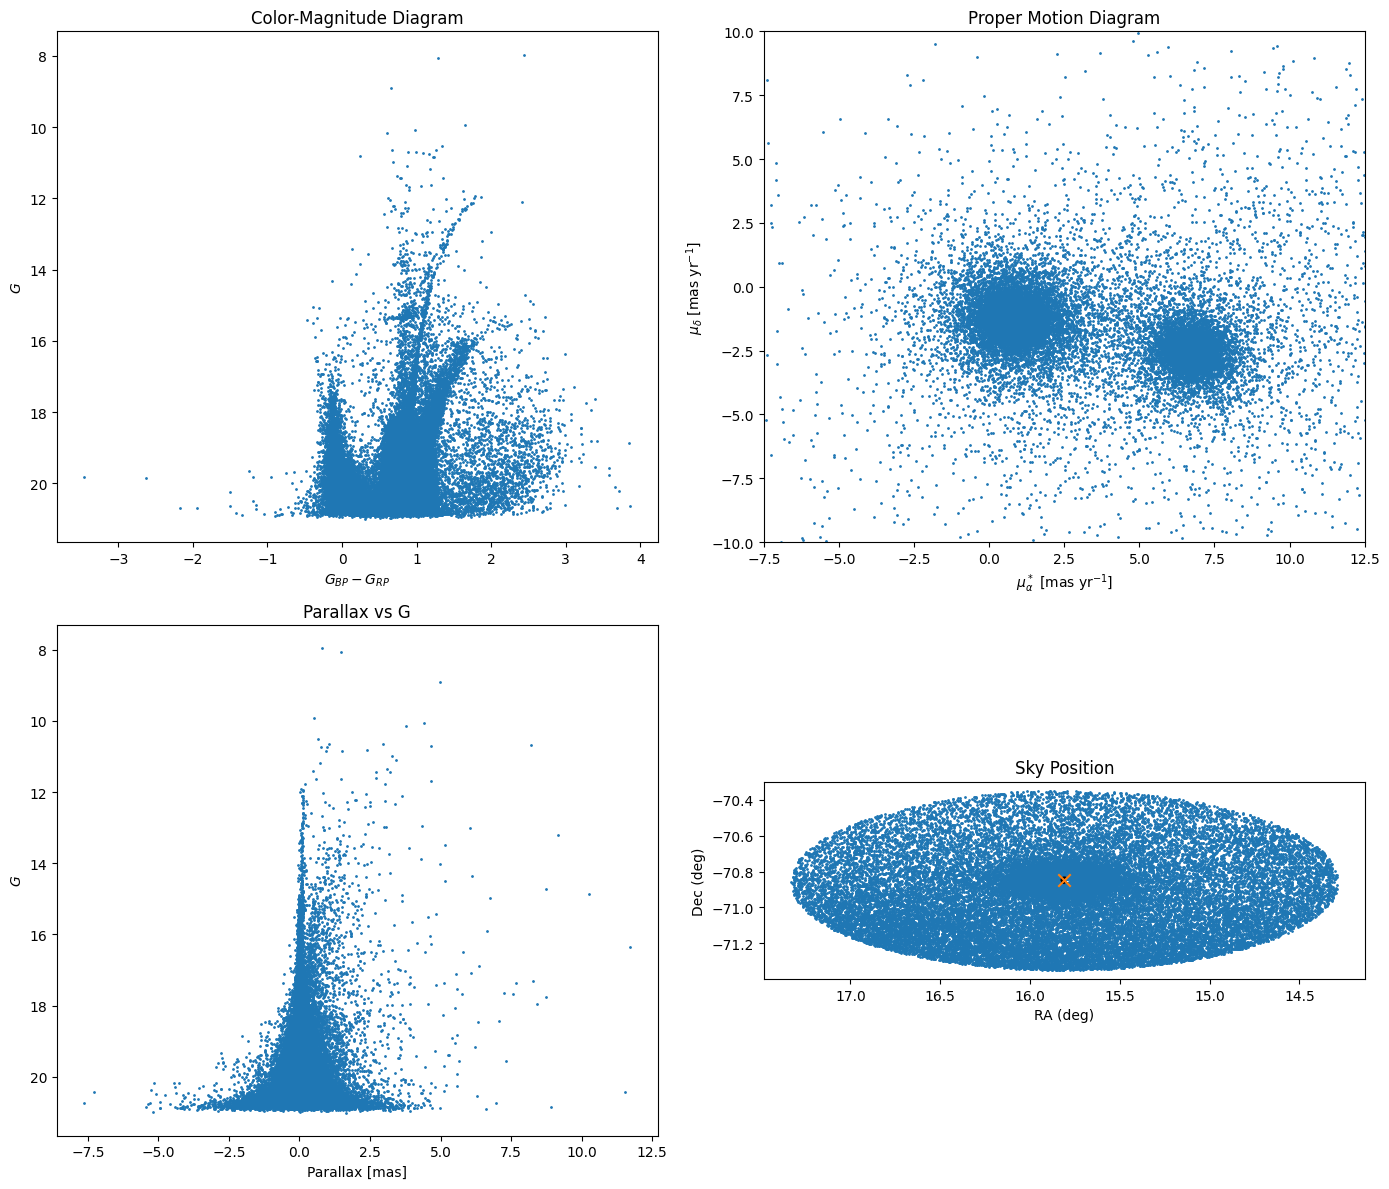

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

# -----------------------------
# 1. Color-Magnitude Diagram
# -----------------------------
ax = axes[0]
ax.scatter(df_clean["bp_rp"], df_clean["phot_g_mean_mag"], s=1)
ax.set_xlabel(r"$G_{BP} - G_{RP}$")
ax.set_ylabel(r"$G$")
ax.set_title("Color-Magnitude Diagram")
ax.invert_yaxis()

# -----------------------------
# 2. Proper motion diagram
# -----------------------------
ax = axes[1]
ax.scatter(df_clean["pmra"], df_clean["pmdec"], s=1)
ax.set_xlim(-7.5, 12.5)
ax.set_ylim(-10, 10)
ax.set_xlabel(r"$\mu_\alpha^*$ [mas yr$^{-1}$]")
ax.set_ylabel(r"$\mu_\delta$ [mas yr$^{-1}$]")
ax.set_title("Proper Motion Diagram")

# -----------------------------
# 3. Parallax vs G
# -----------------------------
ax = axes[2]
ax.scatter(df_clean["parallax"], df_clean["phot_g_mean_mag"], s=1)
ax.set_xlabel("Parallax [mas]")
ax.set_ylabel(r"$G$")
ax.set_title("Parallax vs G")
ax.invert_yaxis()

# -----------------------------
# 4. Sky position
# -----------------------------
ax = axes[3]
ax.scatter(df_clean["ra"], df_clean["dec"], s=1)

# half-light radius circle
circle = Circle((ra_center, dec_center), r_h_deg,
                fill=False, linewidth=2, linestyle='--')
ax.add_patch(circle)

# mark center
ax.scatter(ra_center, dec_center, marker='x', s=80)

#ax.set_xlim(ra_center + query_radius_deg, ra_center - query_radius_deg)
#ax.set_ylim(dec_center - query_radius_deg, dec_center + query_radius_deg)

ax.set_xlabel("RA (deg)")
ax.set_ylabel("Dec (deg)")
ax.set_title("Sky Position")
ax.invert_xaxis()
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

# Step 4

In [9]:
# First-guess cluster proper motion center (from Step 3 plot)
pmra0 = 7.0
pmdec0 = -2.5

# Proper motion cut radius (mas/yr)
r_pm = 3.0

# Circular cut in proper-motion space
pm_dist = np.sqrt((df_clean["pmra"] - pmra0)**2 + (df_clean["pmdec"] - pmdec0)**2)
mask_pm = pm_dist < r_pm

# Loose parallax cut to reject obvious nearby MW contaminants
mask_plx = (df_clean["parallax"] > -0.5) & (df_clean["parallax"] < 0.5)

# Combined first-pass member selection
mask_members_1 = mask_pm & mask_plx

df_members_1 = df_clean[mask_members_1].copy()

print(f"Clean sample: {len(df_clean):,}")
print(f"PM cut only: {mask_pm.sum():,}")
print(f"Parallax cut only: {mask_plx.sum():,}")
print(f"Combined first-pass members: {len(df_members_1):,}")

Clean sample: 36,363
PM cut only: 10,509
Parallax cut only: 26,039
Combined first-pass members: 7,785


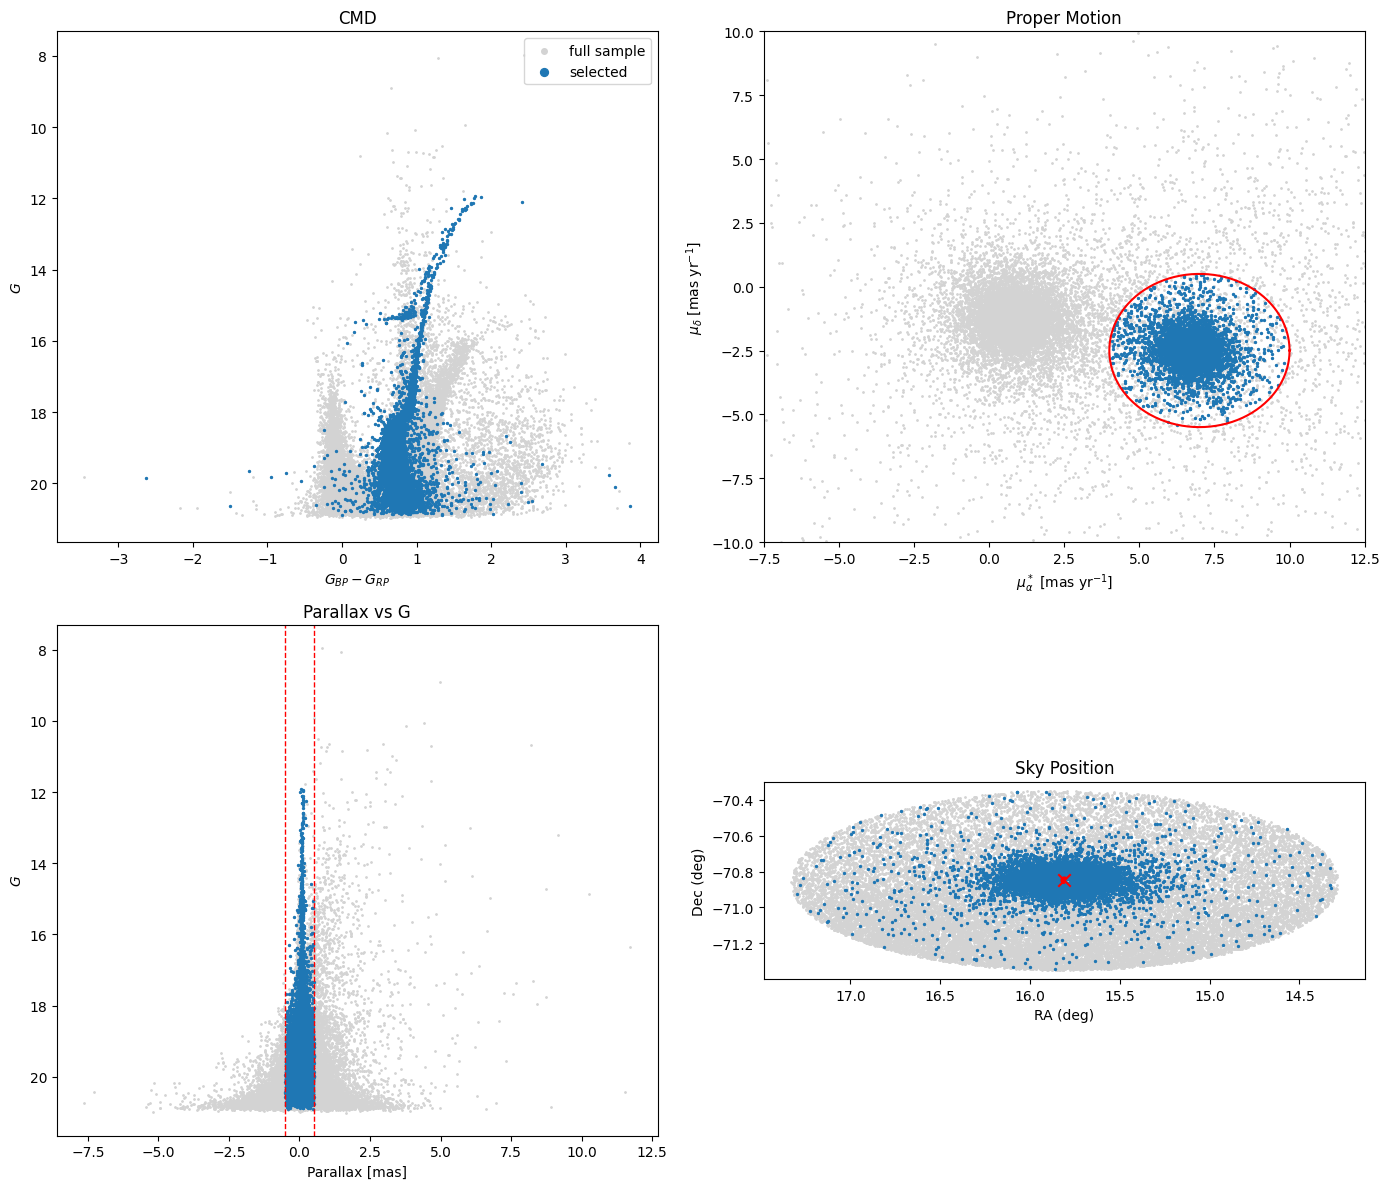

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

bg_color = "lightgray"
sel_color = "tab:blue"

# --------------------------------
# 1. CMD
# --------------------------------
ax = axes[0]
ax.scatter(df_clean["bp_rp"], df_clean["phot_g_mean_mag"], s=1, color=bg_color, label="full sample")
ax.scatter(df_members_1["bp_rp"], df_members_1["phot_g_mean_mag"], s=2, color=sel_color, label="selected")
ax.set_xlabel(r"$G_{BP} - G_{RP}$")
ax.set_ylabel(r"$G$")
ax.set_title("CMD")
ax.invert_yaxis()
ax.legend(markerscale=4)

# --------------------------------
# 2. Proper motion
# --------------------------------
ax = axes[1]
ax.scatter(df_clean["pmra"], df_clean["pmdec"], s=1, color=bg_color)
ax.scatter(df_members_1["pmra"], df_members_1["pmdec"], s=2, color=sel_color)
ax.set_xlim(-7.5, 12.5)
ax.set_ylim(-10, 10)
ax.set_xlabel(r"$\mu_\alpha^*$ [mas yr$^{-1}$]")
ax.set_ylabel(r"$\mu_\delta$ [mas yr$^{-1}$]")
ax.set_title("Proper Motion")

# show selection circle
theta = np.linspace(0, 2*np.pi, 300)
ax.plot(pmra0 + r_pm*np.cos(theta), pmdec0 + r_pm*np.sin(theta), color="red", linewidth=1.5)

# --------------------------------
# 3. Parallax vs G
# --------------------------------
ax = axes[2]
ax.scatter(df_clean["parallax"], df_clean["phot_g_mean_mag"], s=1, color=bg_color)
ax.scatter(df_members_1["parallax"], df_members_1["phot_g_mean_mag"], s=2, color=sel_color)
ax.set_xlabel("Parallax [mas]")
ax.set_ylabel(r"$G$")
ax.set_title("Parallax vs G")
ax.invert_yaxis()

# show parallax cut lines
ax.axvline(-0.5, color="red", linestyle="--", linewidth=1)
ax.axvline(0.5, color="red", linestyle="--", linewidth=1)

# --------------------------------
# 4. Sky position
# --------------------------------
ax = axes[3]
ax.scatter(df_clean["ra"], df_clean["dec"], s=1, color=bg_color)
ax.scatter(df_members_1["ra"], df_members_1["dec"], s=2, color=sel_color)

circle = Circle((ra_center, dec_center), r_h_deg, fill=False, linewidth=2, linestyle='--', edgecolor="red")
ax.add_patch(circle)
ax.scatter(ra_center, dec_center, marker='x', s=80, color="red")

ax.set_xlabel("RA (deg)")
ax.set_ylabel("Dec (deg)")
ax.set_title("Sky Position")
ax.invert_xaxis()
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

In [11]:
pmra0 = 6.8
pmdec0 = -2.3
r_pm = 2.0

pm_dist = np.sqrt((df_clean["pmra"] - pmra0)**2 + (df_clean["pmdec"] - pmdec0)**2)
mask_pm2 = pm_dist < r_pm

mask_plx2 = (df_clean["parallax"] > -0.5) & (df_clean["parallax"] < 0.5)

mask_rad2 = df_clean["radius_arcmin"] < 10.0

mask_members_2 = mask_pm2 & mask_plx2 & mask_rad2
df_members_2 = df_clean[mask_members_2].copy()

print(f"Second-pass members: {len(df_members_2):,}")

Second-pass members: 6,615


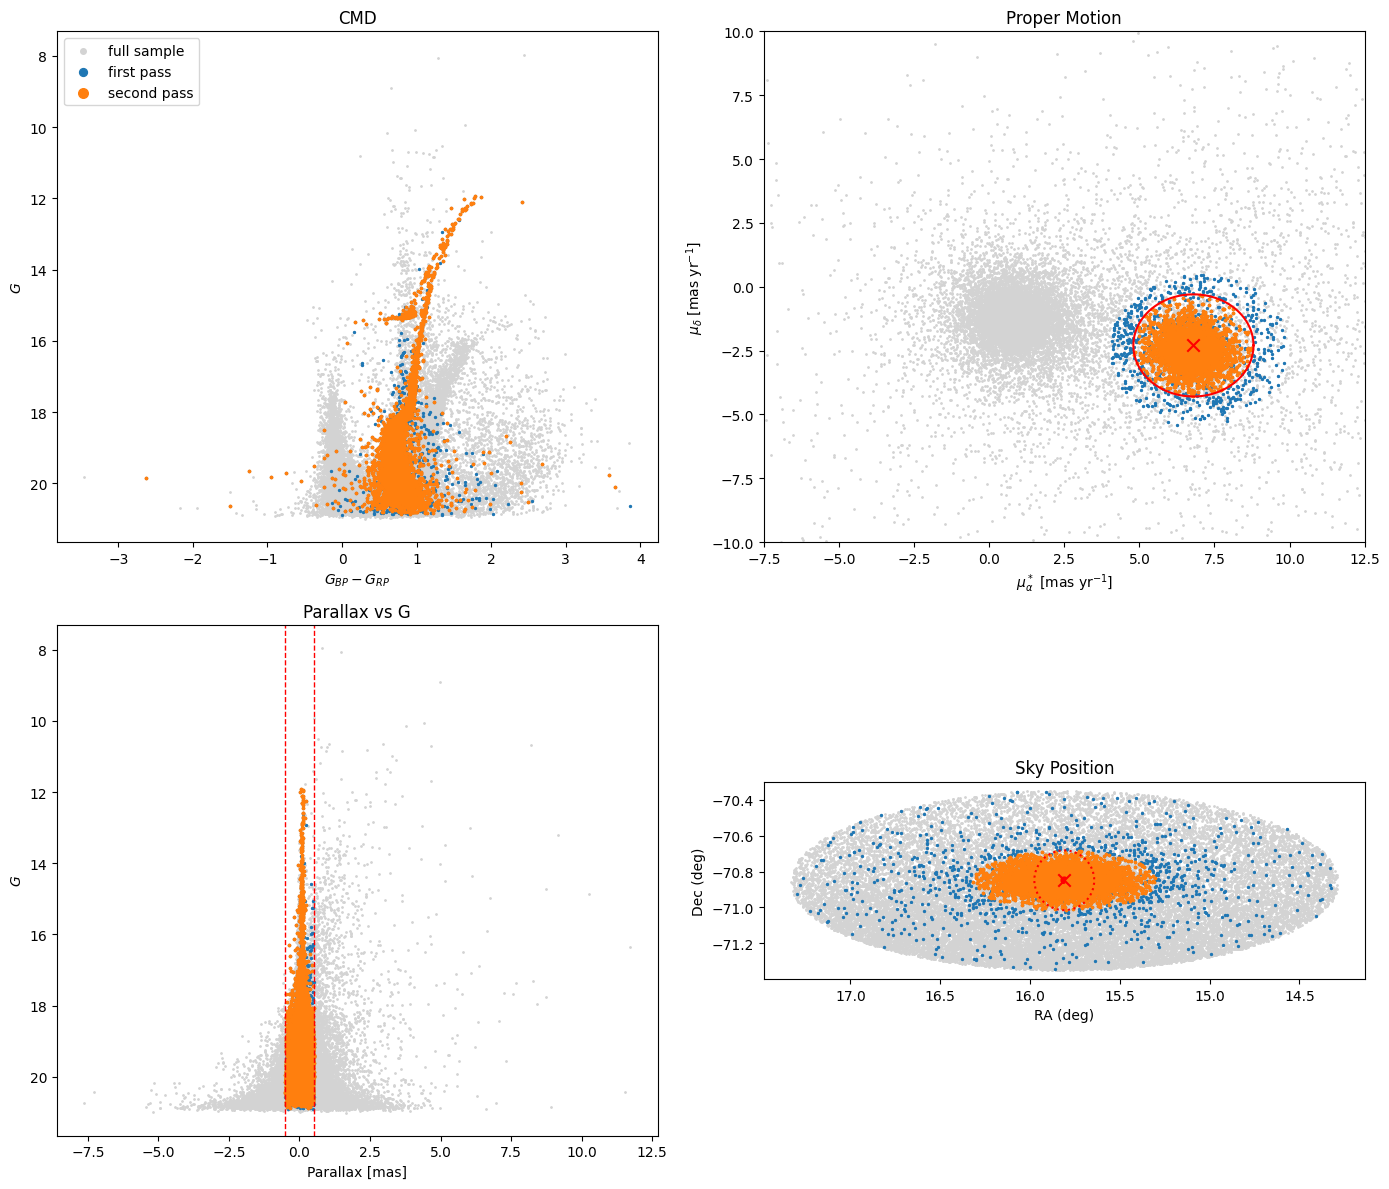

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

bg_color = "lightgray"
sel1_color = "tab:blue"
sel2_color = "tab:orange"

# --------------------------------
# 1. CMD
# --------------------------------
ax = axes[0]
ax.scatter(df_clean["bp_rp"], df_clean["phot_g_mean_mag"], s=1, color=bg_color, label="full sample")
ax.scatter(df_members_1["bp_rp"], df_members_1["phot_g_mean_mag"], s=2, color=sel1_color, label="first pass")
ax.scatter(df_members_2["bp_rp"], df_members_2["phot_g_mean_mag"], s=3, color=sel2_color, label="second pass")
ax.set_xlabel(r"$G_{BP} - G_{RP}$")
ax.set_ylabel(r"$G$")
ax.set_title("CMD")
ax.invert_yaxis()
ax.legend(markerscale=4)

# --------------------------------
# 2. Proper motion
# --------------------------------
ax = axes[1]
ax.scatter(df_clean["pmra"], df_clean["pmdec"], s=1, color=bg_color)
ax.scatter(df_members_1["pmra"], df_members_1["pmdec"], s=2, color=sel1_color)
ax.scatter(df_members_2["pmra"], df_members_2["pmdec"], s=3, color=sel2_color)

ax.set_xlim(-7.5, 12.5)
ax.set_ylim(-10, 10)
ax.set_xlabel(r"$\mu_\alpha^*$ [mas yr$^{-1}$]")
ax.set_ylabel(r"$\mu_\delta$ [mas yr$^{-1}$]")
ax.set_title("Proper Motion")

# show second-pass PM selection circle
theta = np.linspace(0, 2*np.pi, 300)
ax.plot(pmra0 + r_pm*np.cos(theta), pmdec0 + r_pm*np.sin(theta),
        color="red", linewidth=1.5, label="2nd-pass PM cut")

# mark PM center
ax.scatter(pmra0, pmdec0, marker="x", s=80, color="red")

# --------------------------------
# 3. Parallax vs G
# --------------------------------
ax = axes[2]
ax.scatter(df_clean["parallax"], df_clean["phot_g_mean_mag"], s=1, color=bg_color)
ax.scatter(df_members_1["parallax"], df_members_1["phot_g_mean_mag"], s=2, color=sel1_color)
ax.scatter(df_members_2["parallax"], df_members_2["phot_g_mean_mag"], s=3, color=sel2_color)

ax.set_xlabel("Parallax [mas]")
ax.set_ylabel(r"$G$")
ax.set_title("Parallax vs G")
ax.invert_yaxis()

# show parallax cut lines
ax.axvline(-0.5, color="red", linestyle="--", linewidth=1)
ax.axvline(0.5, color="red", linestyle="--", linewidth=1)

# --------------------------------
# 4. Sky position
# --------------------------------
ax = axes[3]
ax.scatter(df_clean["ra"], df_clean["dec"], s=1, color=bg_color)
ax.scatter(df_members_1["ra"], df_members_1["dec"], s=2, color=sel1_color)
ax.scatter(df_members_2["ra"], df_members_2["dec"], s=3, color=sel2_color)

# half-light radius circle
circle = Circle((ra_center, dec_center), r_h_deg,
                fill=False, linewidth=2, linestyle='--', edgecolor="red")
ax.add_patch(circle)

# also show 10 arcmin radial cut
r_cut_deg = 10.0 / 60.0
circle2 = Circle((ra_center, dec_center), r_cut_deg,
                 fill=False, linewidth=1.5, linestyle=':', edgecolor="red")
ax.add_patch(circle2)

ax.scatter(ra_center, dec_center, marker='x', s=80, color="red")

ax.set_xlabel("RA (deg)")
ax.set_ylabel("Dec (deg)")
ax.set_title("Sky Position")
ax.invert_xaxis()
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

# Step 5

In [13]:
# Zoomed proper-motion region for GMM fitting
mask_gmm = (
    (df_clean["pmra"] > -2.0) & (df_clean["pmra"] < 9.5) &
    (df_clean["pmdec"] > -5.5) & (df_clean["pmdec"] < 1.5)
)

df_gmm = df_clean[mask_gmm].copy()

print(f"GMM input sample: {len(df_gmm):,} stars")

GMM input sample: 32,923 stars


In [14]:
from sklearn.mixture import GaussianMixture

X = df_gmm[["pmra", "pmdec"]].to_numpy()
print("Shape of X:", X.shape)

Shape of X: (32923, 2)


In [15]:
gmm2 = GaussianMixture(
    n_components=2,
    covariance_type="full",
    random_state=42
)

gmm2.fit(X)

labels2 = gmm2.predict(X)
probs2 = gmm2.predict_proba(X)

df_gmm = df_gmm.loc[df_gmm[["pmra", "pmdec"]].dropna().index].copy()
df_gmm["gmm2_label"] = labels2
df_gmm["gmm2_prob_max"] = probs2.max(axis=1)

In [16]:
print("2-component GMM means:")
for i, mean in enumerate(gmm2.means_):
    print(f"Component {i}: pmra = {mean[0]:.3f}, pmdec = {mean[1]:.3f}")

2-component GMM means:
Component 0: pmra = 0.817, pmdec = -1.250
Component 1: pmra = 6.585, pmdec = -2.460


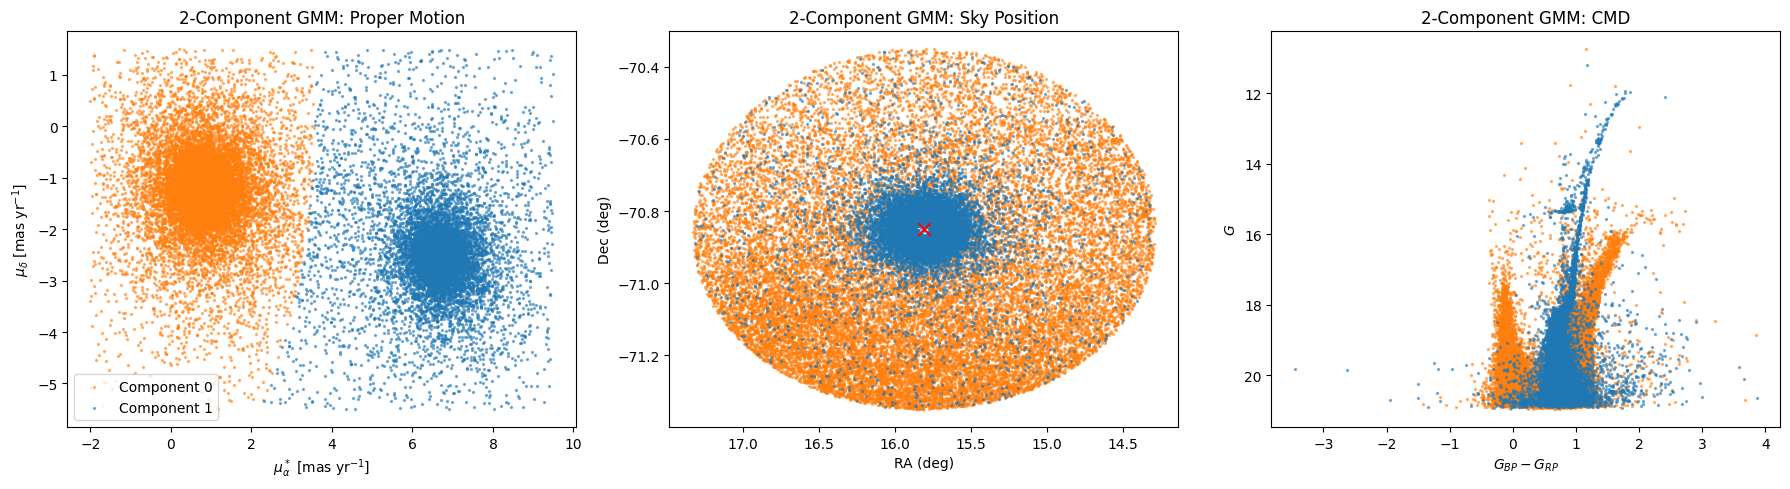

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ["tab:orange", "tab:blue"]

# --------------------------------
# 1. Proper motion
# --------------------------------
ax = axes[0]
for i, color in enumerate(colors):
    m = df_gmm["gmm2_label"] == i
    ax.scatter(df_gmm.loc[m, "pmra"], df_gmm.loc[m, "pmdec"], s=2, alpha=0.5, color=color, label=f"Component {i}")

ax.set_xlabel(r"$\mu_\alpha^*$ [mas yr$^{-1}$]")
ax.set_ylabel(r"$\mu_\delta$ [mas yr$^{-1}$]")
ax.set_title("2-Component GMM: Proper Motion")
ax.legend()

# --------------------------------
# 2. Sky position
# --------------------------------
ax = axes[1]
for i, color in enumerate(colors):
    m = df_gmm["gmm2_label"] == i
    ax.scatter(df_gmm.loc[m, "ra"], df_gmm.loc[m, "dec"], s=2, alpha=0.5, color=color)

ax.scatter(ra_center, dec_center, marker="x", s=80, color="red")
ax.set_xlabel("RA (deg)")
ax.set_ylabel("Dec (deg)")
ax.set_title("2-Component GMM: Sky Position")
ax.invert_xaxis()

# --------------------------------
# 3. CMD
# --------------------------------
ax = axes[2]
for i, color in enumerate(colors):
    m = df_gmm["gmm2_label"] == i
    ax.scatter(df_gmm.loc[m, "bp_rp"], df_gmm.loc[m, "phot_g_mean_mag"], s=2, alpha=0.5, color=color)

ax.set_xlabel(r"$G_{BP} - G_{RP}$")
ax.set_ylabel(r"$G$")
ax.set_title("2-Component GMM: CMD")
ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 3-component model

In [18]:
gmm3 = GaussianMixture(
    n_components=3,
    covariance_type="full",
    random_state=42
)

gmm3.fit(X)

labels3 = gmm3.predict(X)
probs3 = gmm3.predict_proba(X)

df_gmm["gmm3_label"] = labels3
df_gmm["gmm3_prob_max"] = probs3.max(axis=1)

In [19]:
print("3-component GMM means:")
for i, mean in enumerate(gmm3.means_):
    print(f"Component {i}: pmra = {mean[0]:.3f}, pmdec = {mean[1]:.3f}")

3-component GMM means:
Component 0: pmra = 0.783, pmdec = -1.212
Component 1: pmra = 6.715, pmdec = -2.554
Component 2: pmra = 2.940, pmdec = -1.694


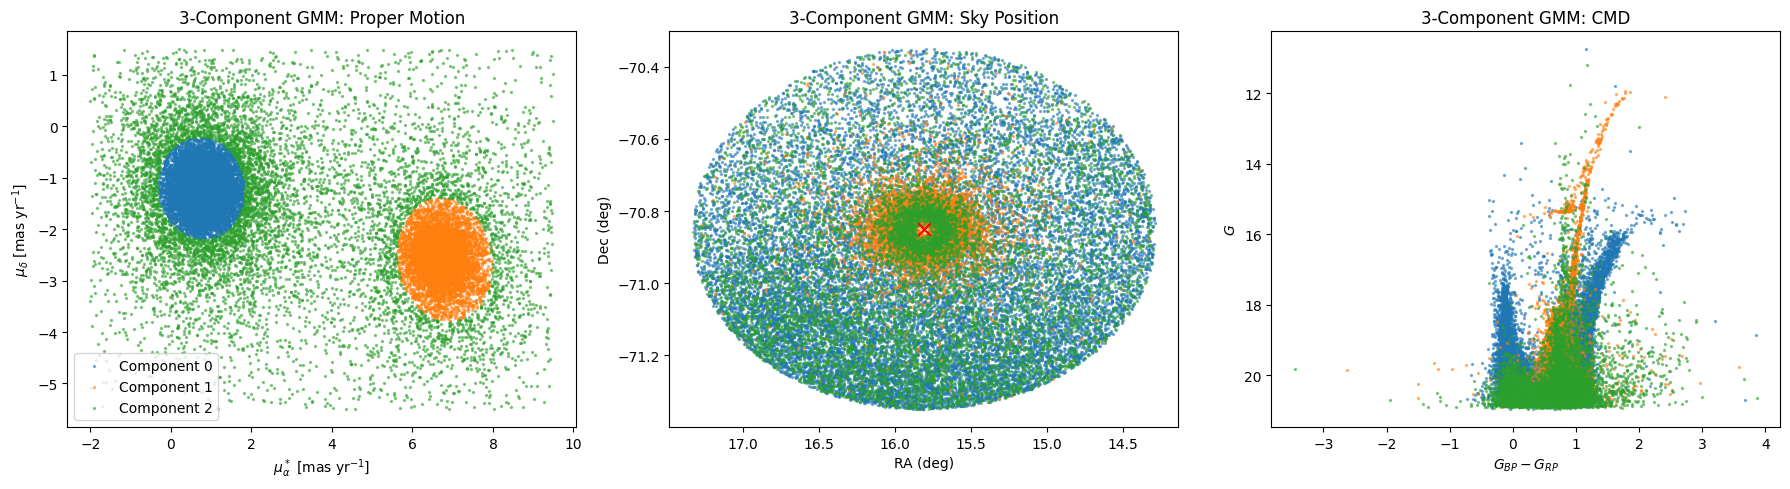

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ["tab:blue", "tab:orange", "tab:green"]

# --------------------------------
# 1. Proper motion
# --------------------------------
ax = axes[0]
for i, color in enumerate(colors):
    m = df_gmm["gmm3_label"] == i
    ax.scatter(
        df_gmm.loc[m, "pmra"],
        df_gmm.loc[m, "pmdec"],
        s=2,
        alpha=0.5,
        color=color,
        label=f"Component {i}"
    )

ax.set_xlabel(r"$\mu_\alpha^*$ [mas yr$^{-1}$]")
ax.set_ylabel(r"$\mu_\delta$ [mas yr$^{-1}$]")
ax.set_title("3-Component GMM: Proper Motion")
ax.legend()

# --------------------------------
# 2. Sky position
# --------------------------------
ax = axes[1]
for i, color in enumerate(colors):
    m = df_gmm["gmm3_label"] == i
    ax.scatter(
        df_gmm.loc[m, "ra"],
        df_gmm.loc[m, "dec"],
        s=2,
        alpha=0.5,
        color=color,
        label=f"Component {i}"
    )

ax.scatter(ra_center, dec_center, marker="x", s=80, color="red")
ax.set_xlabel("RA (deg)")
ax.set_ylabel("Dec (deg)")
ax.set_title("3-Component GMM: Sky Position")
ax.invert_xaxis()

# --------------------------------
# 3. CMD
# --------------------------------
ax = axes[2]
for i, color in enumerate(colors):
    m = df_gmm["gmm3_label"] == i
    ax.scatter(
        df_gmm.loc[m, "bp_rp"],
        df_gmm.loc[m, "phot_g_mean_mag"],
        s=2,
        alpha=0.5,
        color=color,
        label=f"Component {i}"
    )

ax.set_xlabel(r"$G_{BP} - G_{RP}$")
ax.set_ylabel(r"$G$")
ax.set_title("3-Component GMM: CMD")
ax.invert_yaxis()

plt.tight_layout()
plt.show()

## Extract cluster members

In [21]:
cluster_label = 1

cluster_prob = probs3[:, cluster_label]
df_gmm["cluster_prob"] = cluster_prob

df_cluster_gmm = df_gmm[
    (df_gmm["gmm3_label"] == cluster_label) &
    (df_gmm["cluster_prob"] > 0.8)
].copy()

print(f"High-confidence cluster members: {len(df_cluster_gmm):,}")

High-confidence cluster members: 7,354


# Step 6

In [22]:
sigma_pmra = df_cluster_gmm["pmra"].std(ddof=1)
sigma_pmdec = df_cluster_gmm["pmdec"].std(ddof=1)

mean_pmra = df_cluster_gmm["pmra"].mean()
mean_pmdec = df_cluster_gmm["pmdec"].mean()

print(f"Mean pmRA   = {mean_pmra:.4f} mas/yr")
print(f"Mean pmDec  = {mean_pmdec:.4f} mas/yr")
print(f"Sigma pmRA  = {sigma_pmra:.4f} mas/yr")
print(f"Sigma pmDec = {sigma_pmdec:.4f} mas/yr")

Mean pmRA   = 6.7191 mas/yr
Mean pmDec  = -2.5564 mas/yr
Sigma pmRA  = 0.3497 mas/yr
Sigma pmDec = 0.3386 mas/yr


In [23]:
d_kpc = 8.6

sigma_vra = 4.74 * sigma_pmra * d_kpc
sigma_vdec = 4.74 * sigma_pmdec * d_kpc
sigma_v_mean = 0.5 * (sigma_vra + sigma_vdec)

print(f"Sigma vRA   = {sigma_vra:.3f} km/s")
print(f"Sigma vDec  = {sigma_vdec:.3f} km/s")
print(f"Mean sigma v = {sigma_v_mean:.3f} km/s")

Sigma vRA   = 14.256 km/s
Sigma vDec  = 13.801 km/s
Mean sigma v = 14.029 km/s


In [24]:
# Small-angle approximation in degrees, converted to arcmin
df_gmm = df_gmm.copy()

df_gmm["radius_arcmin"] = np.sqrt(
    ((df_gmm["ra"] - ra_center) * np.cos(np.deg2rad(dec_center)))**2 +
    (df_gmm["dec"] - dec_center)**2
) * 60.0

In [25]:
cluster_label = 1
smc_label = 0
mw_label = 2

df_cluster = df_gmm[df_gmm["gmm3_label"] == cluster_label].copy()
df_mw = df_gmm[df_gmm["gmm3_label"] == mw_label].copy()

print(f"Cluster stars: {len(df_cluster):,}")
print(f"MW background stars: {len(df_mw):,}")

Cluster stars: 8,161
MW background stars: 7,989


In [26]:
def radial_density_profile(r_arcmin, bins):
    counts, edges = np.histogram(r_arcmin, bins=bins)
    area = np.pi * (edges[1:]**2 - edges[:-1]**2)   # arcmin^2
    density = counts / area
    centers = 0.5 * (edges[1:] + edges[:-1])
    return centers, density, counts, area

bins = np.arange(0, 30.5, 1.0)   # 1 arcmin bins

r_cluster, dens_cluster, n_cluster, area_cluster = radial_density_profile(
    df_cluster["radius_arcmin"], bins
)

r_mw, dens_mw, n_mw, area_mw = radial_density_profile(
    df_mw["radius_arcmin"], bins
)

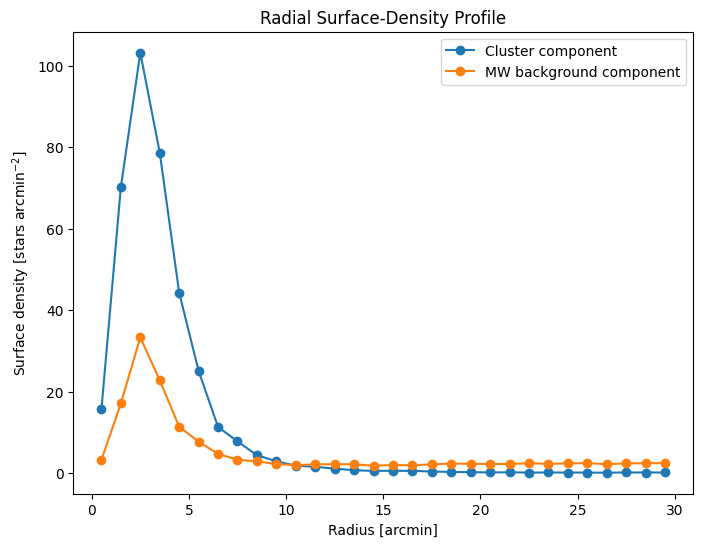

In [27]:
plt.figure(figsize=(8,6))

plt.plot(r_cluster, dens_cluster, marker="o", label="Cluster component")
plt.plot(r_mw, dens_mw, marker="o", label="MW background component")

plt.xlabel("Radius [arcmin]")
plt.ylabel(r"Surface density [stars arcmin$^{-2}$]")
plt.title("Radial Surface-Density Profile")
plt.legend()
plt.show()

In [28]:
diff = dens_cluster - dens_mw

tidal_radius_arcmin = np.nan
for i in range(len(r_cluster)):
    if diff[i] < 0:
        tidal_radius_arcmin = r_cluster[i]
        break

print(f"Estimated tidal radius = {tidal_radius_arcmin:.2f} arcmin")

Estimated tidal radius = 10.50 arcmin


In [29]:
# Mean MW background density at large radii
outer = r_mw > 15
mw_bg_level = dens_mw[outer].mean()

print(f"Mean MW background level = {mw_bg_level:.4f} stars/arcmin^2")

tidal_radius_arcmin_bg = np.nan
for i in range(len(r_cluster)):
    if dens_cluster[i] < mw_bg_level:
        tidal_radius_arcmin_bg = r_cluster[i]
        break

print(f"Tidal radius (using mean MW background) = {tidal_radius_arcmin_bg:.2f} arcmin")

Mean MW background level = 2.2273 stars/arcmin^2
Tidal radius (using mean MW background) = 10.50 arcmin


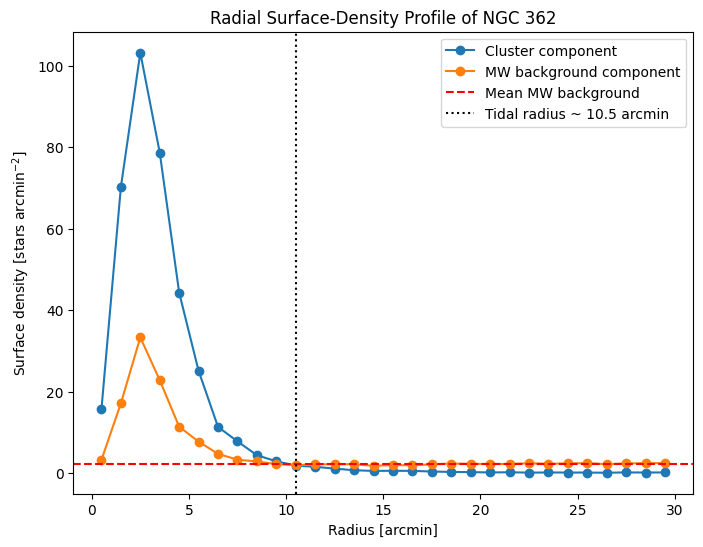

In [30]:
plt.figure(figsize=(8,6))

plt.plot(r_cluster, dens_cluster, marker="o", label="Cluster component")
plt.plot(r_mw, dens_mw, marker="o", label="MW background component")
plt.axhline(mw_bg_level, color="red", linestyle="--", label="Mean MW background")

if not np.isnan(tidal_radius_arcmin_bg):
    plt.axvline(tidal_radius_arcmin_bg, color="black", linestyle=":", 
                label=f"Tidal radius ~ {tidal_radius_arcmin_bg:.1f} arcmin")

plt.xlabel("Radius [arcmin]")
plt.ylabel(r"Surface density [stars arcmin$^{-2}$]")
plt.title("Radial Surface-Density Profile of NGC 362")
plt.legend()
plt.show()

In [31]:
# Convert tidal radius from arcmin to parsecs
# small-angle formula: r = d * theta, with theta in radians

if not np.isnan(tidal_radius_arcmin_bg):
    theta_rad = tidal_radius_arcmin_bg * np.pi / (180.0 * 60.0)
    tidal_radius_pc = d_kpc * 1000.0 * theta_rad

    print(f"Tidal radius = {tidal_radius_arcmin_bg:.2f} arcmin")
    print(f"Tidal radius = {tidal_radius_pc:.2f} pc")
else:
    print("Tidal radius could not be determined.")

Tidal radius = 10.50 arcmin
Tidal radius = 26.27 pc


# Step 7

In [32]:
# Virial theorem mass estimate
# Using G in astrophysical units:
# G = 4.302e-3 pc Msun^-1 (km/s)^2

G_pc = 4.302e-3  # pc Msun^-1 (km/s)^2

M_virial = tidal_radius_pc * sigma_v_mean**2 / G_pc

print(f"Tidal radius = {tidal_radius_pc:.2f} pc")
print(f"Velocity dispersion = {sigma_v_mean:.3f} km/s")
print(f"Virial mass = {M_virial:.3e} Msun")

Tidal radius = 26.27 pc
Velocity dispersion = 14.029 km/s
Virial mass = 1.202e+06 Msun


In [33]:
M_vra = tidal_radius_pc * sigma_vra**2 / G_pc
M_vdec = tidal_radius_pc * sigma_vdec**2 / G_pc
M_vmean = tidal_radius_pc * sigma_v_mean**2 / G_pc

print(f"Mass from sigma_vRA   = {M_vra:.3e} Msun")
print(f"Mass from sigma_vDec  = {M_vdec:.3e} Msun")
print(f"Mass from mean sigma  = {M_vmean:.3e} Msun")

Mass from sigma_vRA   = 1.241e+06 Msun
Mass from sigma_vDec  = 1.163e+06 Msun
Mass from mean sigma  = 1.202e+06 Msun


# Step 8

In [39]:
# Radial bins in arcmin
bins = np.arange(0, 16, 2)   # 0-2, 2-4, ..., 14-16 arcmin

r_centers = []
sigma_pmra_bin = []
sigma_pmdec_bin = []
sigma_pm_mean_bin = []
n_bin = []

for r_in, r_out in zip(bins[:-1], bins[1:]):
    m = (df_cluster_gmm["radius_arcmin"] >= r_in) & (df_cluster_gmm["radius_arcmin"] < r_out)
    sub = df_cluster_gmm[m]

    if len(sub) < 10:
        continue

    s_ra = sub["pmra"].std(ddof=1)
    s_dec = sub["pmdec"].std(ddof=1)
    s_mean = 0.5 * (s_ra + s_dec)

    r_centers.append(0.5 * (r_in + r_out))
    sigma_pmra_bin.append(s_ra)
    sigma_pmdec_bin.append(s_dec)
    sigma_pm_mean_bin.append(s_mean)
    n_bin.append(len(sub))

r_centers = np.array(r_centers)
sigma_pmra_bin = np.array(sigma_pmra_bin)
sigma_pmdec_bin = np.array(sigma_pmdec_bin)
sigma_pm_mean_bin = np.array(sigma_pm_mean_bin)
n_bin = np.array(n_bin)

print("Radial bin centers (arcmin):", r_centers)
print("Stars per bin:", n_bin)

# Convert to km/s
sigma_vra_bin = 4.74 * sigma_pmra_bin * d_kpc
sigma_vdec_bin = 4.74 * sigma_pmdec_bin * d_kpc
sigma_vmean_bin = 4.74 * sigma_pm_mean_bin * d_kpc

Radial bin centers (arcmin): [ 1.  3.  5.  7.  9. 11. 13.]
Stars per bin: [ 636 3009 1909  751  371  204  127]


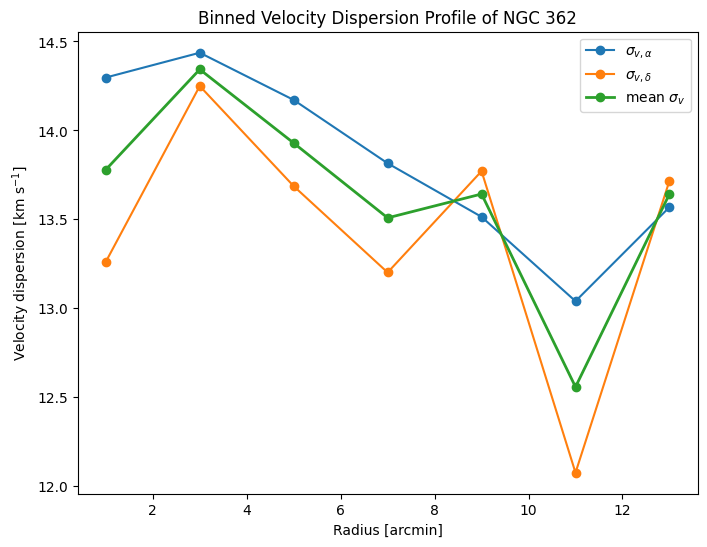

In [40]:
plt.figure(figsize=(8,6))

plt.plot(r_centers, sigma_vra_bin, marker="o", label=r"$\sigma_{v,\alpha}$")
plt.plot(r_centers, sigma_vdec_bin, marker="o", label=r"$\sigma_{v,\delta}$")
plt.plot(r_centers, sigma_vmean_bin, marker="o", linewidth=2, label=r"mean $\sigma_v$")

plt.xlabel("Radius [arcmin]")
plt.ylabel(r"Velocity dispersion [km s$^{-1}$]")
plt.title("Binned Velocity Dispersion Profile of NGC 362")
plt.legend()
plt.show()

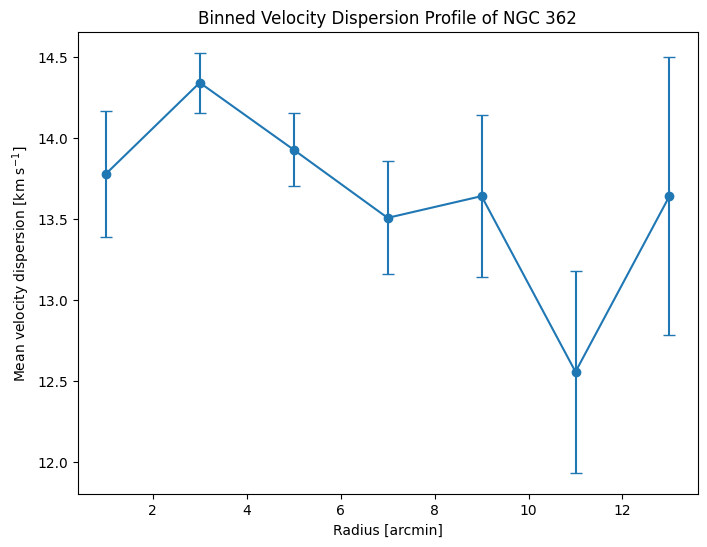

In [41]:
sigma_vmean_err = sigma_vmean_bin / np.sqrt(2 * (n_bin - 1))

plt.figure(figsize=(8,6))
plt.errorbar(r_centers, sigma_vmean_bin, yerr=sigma_vmean_err, fmt="o-", capsize=4)

plt.xlabel("Radius [arcmin]")
plt.ylabel(r"Mean velocity dispersion [km s$^{-1}$]")
plt.title("Binned Velocity Dispersion Profile of NGC 362")
plt.show()